# 🔧 Step 5 — Hyperparameter Tuning with Optuna

**เป้าหมาย:** หาค่า parameter ที่ดีที่สุดให้ LightGBM แบบอัตโนมัติ

---

### Hyperparameter คืออะไร?

Parameter ที่เรา **กำหนดก่อนเทรน** (โมเดลไม่เรียนรู้เอง) เช่น:

| Parameter | ความหมาย | ค่าที่ใช้ใน Step 3 |
|---|---|---|
| `n_estimators` | จำนวน tree ทั้งหมด | 300 |
| `learning_rate` | ก้าวการเรียนรู้ | 0.05 |
| `num_leaves` | ความซับซ้อนของแต่ละ tree | 31 |
| `min_child_samples` | จำนวนข้อมูลขั้นต่ำใน leaf | - |
| `feature_fraction` | สัดส่วน feature ที่ใช้ต่อ tree | - |

---

### ทำไมไม่ลองทุกค่า?

ถ้าแต่ละ parameter มีแค่ 10 ค่า และมี 5 parameter:  
**10⁵ = 100,000 การทดลอง** → เสียเวลามาก!

**Optuna ใช้ Bayesian Optimization:**  
เรียนรู้จาก trial ก่อนหน้า → คาดว่าตรงไหนน่าจะดี → ลองตรงนั้น  
ใช้แค่ **50–100 trial** ก็ได้ผลดีกว่าลองสุ่ม 1,000 trial

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import lightgbm as lgb
import optuna
from sklearn.metrics import (
    roc_auc_score, classification_report,
    accuracy_score, recall_score, f1_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import warnings
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)  # ซ่อน log ที่ไม่จำเป็น

print("Libraries loaded ✓")

Libraries loaded ✓


## 2. โหลดข้อมูล

In [2]:
X_train = pd.read_csv("X_train.csv")
X_test  = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test  = pd.read_csv("y_test.csv").squeeze()

neg   = (y_train == 0).sum()
pos   = (y_train == 1).sum()
scale = neg / pos

print(f"Train: {len(X_train)} แถว | scale_pos_weight: {scale:.2f}")

Train: 614 แถว | scale_pos_weight: 1.86


## 3. Objective Function

> Optuna ทำงานโดยเรียก **objective function** ซ้ำๆ  
> แต่ละครั้ง (`trial`) จะ **แนะนำค่า parameter ชุดใหม่** ให้ลอง  
> เราวัดผลด้วย **AUC-ROC บน Cross-Validation** แล้วส่งค่ากลับ  
> Optuna จะเรียนรู้ว่าค่าไหนดีและลองค่าใกล้เคียงกันต่อ

> **Cross-Validation (CV) คืออะไร?**  
> แบ่ง train เป็น 5 ส่วน เทรนบน 4 ส่วน ทดสอบบน 1 ส่วน ทำซ้ำ 5 รอบ  
> → ได้ค่าเฉลี่ยที่เชื่อถือได้กว่าการ split ครั้งเดียว

In [3]:
def objective(trial):
    # Optuna แนะนำค่า parameter ชุดใหม่ทุก trial
    params = {
        "n_estimators":      trial.suggest_int("n_estimators",      100, 1000),
        "learning_rate":     trial.suggest_float("learning_rate",   0.01, 0.3,  log=True),
        "num_leaves":        trial.suggest_int("num_leaves",        10,   150),
        "min_child_samples": trial.suggest_int("min_child_samples", 5,    100),
        "feature_fraction":  trial.suggest_float("feature_fraction",0.5,  1.0),
        "bagging_fraction":  trial.suggest_float("bagging_fraction",0.5,  1.0),
        "bagging_freq":      trial.suggest_int("bagging_freq",      1,    7),
        "scale_pos_weight":  scale,
        "random_state":      42,
        "verbose":           -1,
    }

    model = lgb.LGBMClassifier(**params)

    # 5-Fold Cross-Validation → ได้ค่าเฉลี่ย AUC-ROC
    cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores  = cross_val_score(model, X_train, y_train,
                              scoring="roc_auc", cv=cv, n_jobs=-1)
    return scores.mean()   # ส่งค่ากลับให้ Optuna ปรับปรุงครั้งต่อไป

print("Objective function พร้อมแล้ว ✓")

Objective function พร้อมแล้ว ✓


## 4. รัน Optuna (50 Trials)

In [ ]:
study = optuna.create_study(direction="maximize")   # maximize AUC-ROC
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n=== ผลลัพธ์ Optimization ===")
print(f"Best AUC-ROC (CV) : {study.best_value:.4f}")
print(f"Best Parameters   :")
for k, v in study.best_params.items():
    print(f"  {k:<22} = {v}")

  0%|          | 0/50 [00:00<?, ?it/s]


=== ผลลัพธ์ Optimization ===
Best AUC-ROC (CV) : 0.9777
Best Parameters   :
  n_estimators           = 285
  learning_rate          = 0.01711289785418689
  num_leaves             = 62
  min_child_samples      = 31
  feature_fraction       = 0.5001911434656735
  bagging_fraction       = 0.7075072404812682
  bagging_freq           = 7


## 5. เทรนโมเดลสุดท้ายด้วย Best Parameters

In [5]:
best_params = study.best_params.copy()
best_params["scale_pos_weight"] = scale
best_params["random_state"]     = 42
best_params["verbose"]          = -1

tuned_model = lgb.LGBMClassifier(**best_params)
tuned_model.fit(X_train, y_train)

y_pred_tuned = tuned_model.predict(X_test)
y_prob_tuned = tuned_model.predict_proba(X_test)[:, 1]

auc_tuned  = roc_auc_score(y_test, y_prob_tuned)
acc_tuned  = accuracy_score(y_test, y_pred_tuned)

print(f"Tuned LightGBM → Accuracy: {acc_tuned:.4f}  |  AUC-ROC: {auc_tuned:.4f}")

Tuned LightGBM → Accuracy: 0.9026  |  AUC-ROC: 0.9800


## 6. เปรียบเทียบ Default vs Tuned

In [6]:
# Default model จาก Step 3
default_model = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    scale_pos_weight=scale, random_state=42, verbose=-1
)
default_model.fit(X_train, y_train)
y_pred_default = default_model.predict(X_test)
y_prob_default = default_model.predict_proba(X_test)[:, 1]

auc_default = roc_auc_score(y_test, y_prob_default)
acc_default = accuracy_score(y_test, y_pred_default)

results = pd.DataFrame({
    "Model":    ["LightGBM Default", "LightGBM Tuned"],
    "Accuracy": [round(acc_default, 4), round(acc_tuned, 4)],
    "AUC-ROC":  [round(auc_default, 4), round(auc_tuned, 4)],
    "Recall":   [
        round(recall_score(y_test, y_pred_default), 4),
        round(recall_score(y_test, y_pred_tuned),   4),
    ],
    "F1":       [
        round(f1_score(y_test, y_pred_default), 4),
        round(f1_score(y_test, y_pred_tuned),   4),
    ],
})
results.set_index("Model")

,Accuracy,AUC-ROC,Recall,F1
Model,,,,
LightGBM Default,0.8961,0.968,0.9074,0.8596
LightGBM Tuned,0.9026,0.980,0.9630,0.8739


In [7]:
print("=== Tuned Model Classification Report ===")
print(classification_report(y_test, y_pred_tuned,
      target_names=["No Diabetes", "Diabetes"]))

=== Tuned Model Classification Report ===
              precision    recall  f1-score   support

 No Diabetes       0.98      0.87      0.92       100
    Diabetes       0.80      0.96      0.87        54

    accuracy                           0.90       154
   macro avg       0.89      0.92      0.90       154
weighted avg       0.92      0.90      0.90       154



## 7. Visualization — Optimization History + Parameter Importance

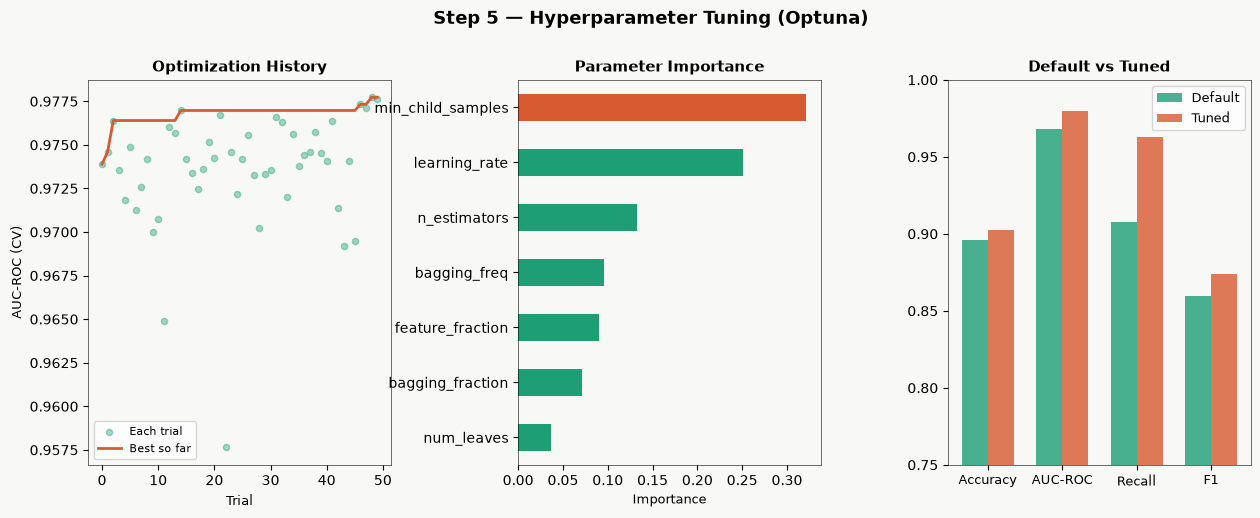

Saved: step5_tuning.png


In [8]:
fig = plt.figure(figsize=(15, 5))
fig.patch.set_facecolor("#F8F8F6")
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.42)

# --- Plot 1: Optimization History ---
ax1 = fig.add_subplot(gs[0])
trial_nums  = [t.number for t in study.trials]
trial_vals  = [t.value  for t in study.trials]
best_so_far = pd.Series(trial_vals).cummax().values

ax1.scatter(trial_nums, trial_vals, alpha=0.4, s=20,
            color="#1D9E75", label="Each trial")
ax1.plot(trial_nums, best_so_far, color="#D85A30",
         lw=2, label="Best so far")
ax1.set_xlabel("Trial", fontsize=9)
ax1.set_ylabel("AUC-ROC (CV)", fontsize=9)
ax1.set_title("Optimization History", fontsize=11, fontweight="bold")
ax1.legend(fontsize=8)
ax1.set_facecolor("#F8F8F6")
for spine in ax1.spines.values(): spine.set_linewidth(0.4)

# --- Plot 2: Parameter Importance ---
ax2 = fig.add_subplot(gs[1])
try:
    param_imp = optuna.importance.get_param_importances(study)
    imp_series = pd.Series(param_imp).sort_values()
    colors_bar = ["#D85A30" if v == imp_series.max() else "#1D9E75"
                  for v in imp_series.values]
    imp_series.plot(kind="barh", ax=ax2, color=colors_bar)
    ax2.set_title("Parameter Importance", fontsize=11, fontweight="bold")
    ax2.set_xlabel("Importance", fontsize=9)
except Exception:
    ax2.text(0.5, 0.5, "Not enough trials", ha="center", va="center", transform=ax2.transAxes)
ax2.set_facecolor("#F8F8F6")
for spine in ax2.spines.values(): spine.set_linewidth(0.4)

# --- Plot 3: Default vs Tuned bar chart ---
ax3 = fig.add_subplot(gs[2])
metrics = ["Accuracy", "AUC-ROC", "Recall", "F1"]
default_vals = [
    acc_default,
    auc_default,
    recall_score(y_test, y_pred_default),
    f1_score(y_test, y_pred_default),
]
tuned_vals = [
    acc_tuned,
    auc_tuned,
    recall_score(y_test, y_pred_tuned),
    f1_score(y_test, y_pred_tuned),
]
x = np.arange(len(metrics))
w = 0.35
ax3.bar(x - w/2, default_vals, width=w, color="#1D9E75", alpha=0.8, label="Default")
ax3.bar(x + w/2, tuned_vals,   width=w, color="#D85A30", alpha=0.8, label="Tuned")
ax3.set_xticks(x)
ax3.set_xticklabels(metrics, fontsize=9)
ax3.set_ylim(0.75, 1.0)
ax3.set_title("Default vs Tuned", fontsize=11, fontweight="bold")
ax3.legend(fontsize=9)
ax3.set_facecolor("#F8F8F6")
for spine in ax3.spines.values(): spine.set_linewidth(0.4)

fig.suptitle("Step 5 — Hyperparameter Tuning (Optuna)",
             fontsize=13, fontweight="bold", y=1.02)
plt.savefig("step5_tuning.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved: step5_tuning.png")

## ✅ สรุป Step 5

### สิ่งที่ได้เรียน

| Concept | ความหมาย |
|---|---|
| **Hyperparameter** | ค่าที่เรากำหนดก่อนเทรน โมเดลไม่เรียนรู้เอง |
| **Bayesian Optimization** | เรียนรู้จาก trial ก่อนหน้า ไม่ลองสุ่ม |
| **Objective Function** | ฟังก์ชันที่ Optuna พยายาม maximize |
| **Cross-Validation** | แบ่ง train 5 ส่วน วัดผลน่าเชื่อถือกว่า |
| **Parameter Importance** | บอกว่า parameter ไหนส่งผลต่อ AUC มากที่สุด |

---
➡️ **Step ถัดไป → Step 6: Pipeline & Save Model** — บันทึกโมเดลที่ดีที่สุดพร้อม deploy ใช้งานจริง